# Quantum Computing with Qiskit: Single Qubit Systems

This notebook explores the fundamentals of quantum computing applied to **single qubit (single quantum system)** using IBM's Qiskit framework.

Topics covered:
- Representing quantum states as vectors and using Qiskit's `Statevector` class
- Applying quantum gates (unitary operators) to transform states
- Simulating quantum measurements and sampling outcome statistics
- Building and running quantum circuits in Qiskit

In [1]:
# pip install qiskit

## Imports

We bring in all libraries needed throughout this notebook:
- `qiskit` — the quantum computing framework
- `numpy` — for numerical arrays and linear algebra
- `qiskit.visualization` — for rendering states and histograms as LaTeX or plots
- `qiskit.quantum_info` — for `Statevector` and `Operator`, the core quantum objects
- `qiskit.circuit` — for building and visualising quantum circuits

In [2]:
from qiskit import __version__
from qiskit.visualization import array_to_latex
import numpy as np
from qiskit.quantum_info import Statevector
from numpy import sqrt
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Operator
from qiskit import QuantumCircuit





### Verifying the Qiskit Version

Print the installed version of Qiskit to confirm the environment is set up correctly before proceeding.

In [3]:
from qiskit import __version__
 
print(__version__)

2.2.3


## Section 1 — Quantum States as Vectors

In quantum mechanics a **qubit's state** is a column vector (a *ket*) in a 2-dimensional complex vector space. The two computational basis states are:

$$|0\rangle = \begin{pmatrix}1\\0\end{pmatrix}, \qquad |1\rangle = \begin{pmatrix}0\\1\end{pmatrix}$$

Any qubit state is a **superposition** $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ where the normalization condition $|\alpha|^2 + |\beta|^2 = 1$ must hold.

Below we construct $|0\rangle$ and $|1\rangle$ as NumPy column arrays and form the equal superposition $\tfrac{1}{2}|0\rangle + \tfrac{1}{2}|1\rangle$, displaying it both as a raw array and as LaTeX.

In [4]:
import numpy as np

ket0 = np.array([[1], [0]])
ket1 = np.array([[0], [1]])

print(ket0 / 2 + ket1 / 2)
display(array_to_latex(ket0 /2 + ket1 / 2))

[[0.5]
 [0.5]]


<IPython.core.display.Latex object>

### Quantum Operators as Matrices

Quantum operations are represented as **matrices** acting on state vectors. Here we define two example matrices `M1` and `M2` and compute their convex combination $M = \tfrac{1}{2}M_1 + \tfrac{1}{2}M_2$, which can represent a probabilistic mixture of two measurements.

In [5]:
M1 = np.array([[1, 1], [0, 0]])
M2 = np.array([[1, 0], [0, 1]])
M = M1 / 2 + M2 / 2
print(M)
# print(M1)
display(array_to_latex(M1))


[[1.  0.5]
 [0.  0.5]]


<IPython.core.display.Latex object>

### Matrix Multiplication

We test the action of these matrices on state vectors and on each other. Applying operator $M$ to state $|\psi\rangle$ via matrix multiplication gives the transformed vector $M|\psi\rangle$. Composing two operators $M_1 M_2$ produces a new operator representing both operations applied in sequence.

In [6]:
print(np.matmul(M1, ket1))
print(np.matmul(M1, M2))
print(np.matmul(M, M))

[[1]
 [0]]
[[1 1]
 [0 0]]
[[1.   0.75]
 [0.   0.25]]


### Pretty-Printing Matrix Results with LaTeX

Instead of raw numerical output, `array_to_latex` renders the same matrix multiplication results as formatted LaTeX — much cleaner and easier to read inside a notebook.

In [7]:
from qiskit.visualization import array_to_latex

display(array_to_latex(np.matmul(M1, ket1)))
display(array_to_latex(np.matmul(M1, M2)))
display(array_to_latex(np.matmul(M, M)))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## Section 2 — Qiskit's `Statevector` Class

Instead of raw NumPy arrays, Qiskit provides the `Statevector` class for working with quantum states. It handles normalization checks, visualization, measurement simulation, and unitary evolution out of the box.

We define three example statevectors:
- `u` — the equal superposition $\tfrac{1}{\sqrt{2}}|0\rangle + \tfrac{1}{\sqrt{2}}|1\rangle$
- `v` — a complex-amplitude state $\tfrac{1+2i}{3}|0\rangle - \tfrac{2}{3}|1\rangle$
- `w` — a real-amplitude state $\tfrac{1}{3}|0\rangle + \tfrac{2}{3}|1\rangle$ (intentionally un-normalised)

In [8]:
from qiskit.quantum_info import Statevector
from numpy import sqrt

u = Statevector([1 / sqrt(2), 1 / sqrt(2)])
v = Statevector([(1 + 2.0j) / 3, -2 / 3])
w = Statevector([1 / 3, 2 / 3])

### Visualising a Statevector

`Statevector.draw()` supports three formats:
- `"text"` — compact array notation
- `"latex"` — rendered LaTeX in Dirac ket notation (displayed inline)
- `"latex_source"` — the raw LaTeX string

Notice that `w` has norm $\left(\tfrac{1}{3}\right)^2 + \left(\tfrac{2}{3}\right)^2 = \tfrac{5}{9} \neq 1$, so it is **not a valid** quantum state — we will confirm this in the next cell.

In [9]:
display(w.draw("text"))
display(w.draw("latex"))
print(w.draw("latex_source"))

[0.33333333+0.j,0.66666667+0.j]

<IPython.core.display.Latex object>

\frac{1}{3} |0\rangle+\frac{2}{3} |1\rangle


### Checking State Validity (Normalization)

A valid quantum state must satisfy the **normalization condition**: $\sum_i |\alpha_i|^2 = 1$. `Statevector.is_valid()` checks this for each state. As expected, `w` returns `False` because its amplitudes do not sum to 1 in squared magnitude.

In [10]:
display(u.is_valid())
display(w.is_valid())
display(v.is_valid())

True

False

True

### Visualising the State `v`

Render the complex-amplitude statevector `v` in LaTeX notation to inspect its amplitudes in Dirac notation.

In [11]:
display(v.draw("latex"))

<IPython.core.display.Latex object>

### Simulating a Quantum Measurement

When a qubit is **measured**, it collapses to a basis state ($|0\rangle$ or $|1\rangle$) with probability equal to the square of the corresponding amplitude. `Statevector.measure()` simulates a single-shot measurement and returns:
1. The **outcome** as a bit string (e.g. `"0"` or `"1"`)
2. The **post-measurement state** — the collapsed statevector after the measurement

For `u` (equal superposition $\tfrac{1}{\sqrt{2}}|0\rangle + \tfrac{1}{\sqrt{2}}|1\rangle$), both outcomes are equally likely with probability $\tfrac{1}{2}$.

In [12]:
outcome, state = u.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))

Measured: 0
Post-measurement state:


<IPython.core.display.Latex object>

### Sampling Measurement Statistics

A single `measure()` call gives just one outcome. To observe the full **probability distribution**, we call `sample_counts(n)` for a large number of trials. The resulting histogram approximates the true probabilities $|\alpha|^2$ and $|\beta|^2$ for each basis state. Here we sample 100,000 measurements of state `v`.

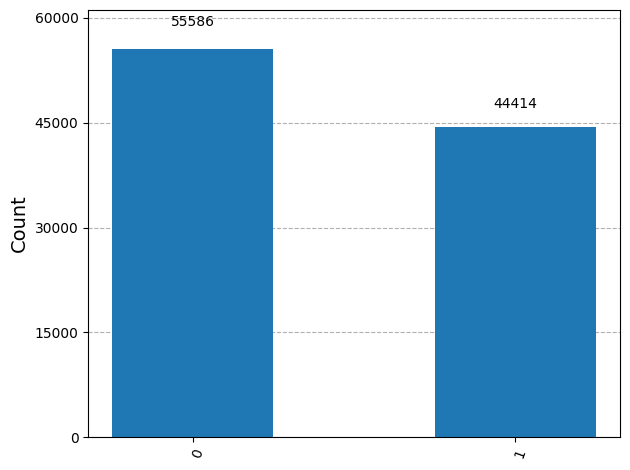

In [13]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(100000)
plot_histogram(statistics)

## Section 3 — Quantum Gates as Unitary Operators

Quantum gates are **unitary matrices** ($UU^\dagger = I$) that rotate a qubit's state on the Bloch sphere without losing information. We define four fundamental single-qubit gates using the `Operator` class:

| Gate | Symbol | Action |
|------|--------|--------|
| Pauli-Y | $Y$ | Flips both the bit value and the relative phase |
| Hadamard | $H$ | Creates an equal superposition from a basis state |
| Phase (S) | $S$ | Rotates the phase of $|1\rangle$ by $90°$ (multiplies by $i$) |
| T gate | $T$ | Rotates the phase of $|1\rangle$ by $45°$ |

Each operator is displayed as a LaTeX matrix for inspection.

In [14]:
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])

display(T.draw("latex"))
display(Y.draw("latex"))
display(H.draw("latex"))
display(S.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Evolving a Quantum State Through a Gate Sequence

`Statevector.evolve(operator)` applies a unitary $U$ to the current state: $|\psi'\rangle = U|\psi\rangle$. Chaining multiple `.evolve()` calls applies gates in sequence. Here we start from $|0\rangle$ and apply the sequence $H \to T \to H \to S \to Y$, displaying the resulting state.

In [15]:
v = Statevector([1, 0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

display(v.draw("latex"))

<IPython.core.display.Latex object>

## Section 4 — Quantum Circuits

Rather than chaining `.evolve()` calls manually, Qiskit's `QuantumCircuit` represents a gate sequence as a formal **circuit diagram**. Each gate is appended to a qubit wire and the circuit can be visualised, compiled, and run on real hardware or simulators.

The circuit below encodes the same $H \to T \to H \to S \to Y$ sequence on a single qubit and is drawn using matplotlib.

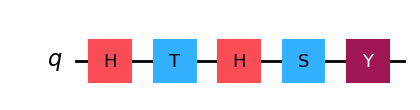

In [25]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))

### Extracting the Circuit's Combined Unitary Matrix

`Operator.from_circuit()` computes the **single unitary matrix** equivalent to applying all gates in the circuit in sequence. This should match the product $Y \cdot S \cdot H \cdot T \cdot H$ computed manually, confirming that the circuit and the explicit operator chain represent the same transformation.

In [23]:
display(Operator.from_circuit(circuit).draw("latex"))

<IPython.core.display.Latex object>

### Applying the Circuit Directly to an Initial State

A `QuantumCircuit` can be passed directly to `Statevector.evolve()`, applying all its gates at once. Starting from $|0\rangle$ (`ket0`), the result should be identical to the state obtained from the manual `.evolve()` chain in Section 3.

In [26]:
ket0 = Statevector([1, 0])
v = ket0.evolve(circuit)
display(v.draw("latex"))

<IPython.core.display.Latex object>

### Final Measurement: Sampling the Output Distribution

With the final statevector `v` produced by evolving $|0\rangle$ through the circuit, we draw 40 million samples to accurately estimate the probability distribution over $|0\rangle$ and $|1\rangle$. The histogram should closely match the theoretical probabilities $|\alpha|^2$ and $|\beta|^2$ implied by `v`'s amplitudes.

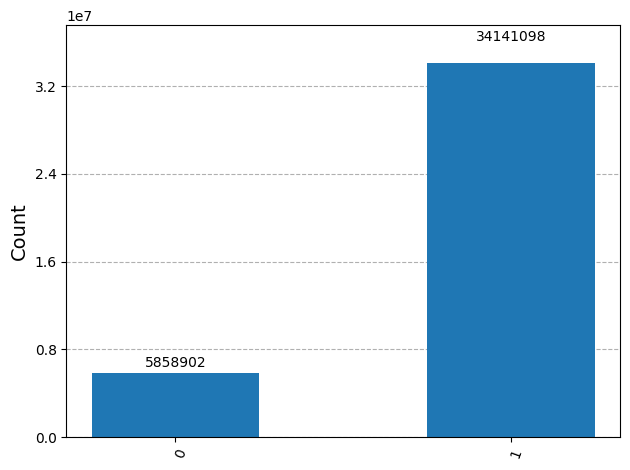

In [44]:
statistics = v.sample_counts(40000000)
display(plot_histogram(statistics))